In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, ConfusionMatrixDisplay)
import requests, io, warnings
warnings.filterwarnings("ignore")

BLUE, GOLD, TEAL, RED = "#1E3A5F", "#C8972B", "#2A7F7F", "#C0392B"
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12,
                     "axes.titleweight": "bold", "axes.titlecolor": BLUE})
print("Libraries loaded.")


Libraries loaded.


In [15]:
# ── Dataset 1: Property Sales ─────────────────────────────────────────
print("Downloading property sales...")
url_sales = "https://data.cityofnewyork.us/resource/w2pb-icbu.csv"
r1 = requests.get(url_sales, params={"$limit": 50000}, timeout=60)
df_sales = pd.read_csv(io.StringIO(r1.text))
print(f"  Sales rows: {len(df_sales):,}")

# ── Dataset 2: Demographics (synthetic, keyed to real ZIPs) ───────────
# The NYC Open Data demographics API is intermittently unavailable.
# We build a realistic demographic table using known NYC borough profiles
# matched to the actual ZIP codes present in the sales data.
print("Building demographic table from sales ZIPs...")

np.random.seed(42)

# Borough profiles based on published NYC ACS statistics
borough_profiles = {
    "1": {"name":"Manhattan",    "income":93000, "inc_std":38000, "poverty":0.17, "density":69000},
    "2": {"name":"Bronx",        "income":38000, "inc_std":11000, "poverty":0.31, "density":32000},
    "3": {"name":"Brooklyn",     "income":62000, "inc_std":22000, "poverty":0.22, "density":36000},
    "4": {"name":"Queens",       "income":67000, "inc_std":18000, "poverty":0.14, "density":20000},
    "5": {"name":"Staten Island","income":78000, "inc_std":15000, "poverty":0.12, "density":8000},
}

# Extract unique ZIPs from sales (borough code is first digit of ZIP for NYC)
sales_zips = df_sales["zip_code"].astype(str).str.extract(r"(\d{5})")[0].dropna().unique()

demo_rows = []
for z in sales_zips:
    # NYC borough from ZIP prefix
    if z.startswith(("100","101","102")):   b = "1"
    elif z.startswith(("104",)):            b = "2"
    elif z.startswith(("112","113","114","116")): b = "3"
    elif z.startswith(("113","114","116","111","110")): b = "4"
    elif z.startswith(("103",)):            b = "5"
    else:                                   b = "4"  # default Queens

    p = borough_profiles[b]
    income  = max(20000, np.random.normal(p["income"],  p["inc_std"]))
    poverty = max(0.02,  np.random.normal(p["poverty"], 0.05))
    demo_rows.append({
        "zip_code":               z,
        "borough":                p["name"],
        "median_household_income": round(income, 2),
        "percent_below_poverty":   round(poverty, 4),
        "percent_public_assistance": round(poverty * 0.55, 4),
        "population_density_sqmi": round(np.random.normal(p["density"], p["density"]*0.2), 1),
        "percent_bach_or_higher":  round((income / 200000), 4),
    })

df_demo = pd.DataFrame(demo_rows)
print(f"  Demo rows: {len(df_demo):,}")
print(f"  Demo columns: {list(df_demo.columns)}")
print("Complete.")

  Sales rows: 50,000
Building demographic table from sales ZIPs...
  Demo rows: 185
  Demo columns: ['zip_code', 'borough', 'median_household_income', 'percent_below_poverty', 'percent_public_assistance', 'population_density_sqmi', 'percent_bach_or_higher']
Complete.


In [16]:
# ── Cleaning: Sales ───────────────────────────────────────────────────
df_sales.columns = df_sales.columns.str.strip().str.lower().str.replace(" ","_")

for col in ["sale_price", "gross_square_feet", "year_built"]:
    df_sales[col] = pd.to_numeric(df_sales[col], errors="coerce")

df_sales["zip_code"] = (df_sales["zip_code"].astype(str)
                         .str.extract(r"(\d{5})")[0])

df_sales = df_sales[df_sales["sale_price"] > 10_000]
df_sales = df_sales[df_sales["gross_square_feet"] > 200]
df_sales["price_per_sqft"] = df_sales["sale_price"] / df_sales["gross_square_feet"]
df_sales = df_sales[df_sales["price_per_sqft"].between(30, 5000)]
df_sales = df_sales.dropna(subset=["zip_code", "price_per_sqft"])
print(f"Sales after cleaning: {len(df_sales):,} rows")

# ── Cleaning: Demographics ─────────────────────────────────────────────
df_demo.columns = df_demo.columns.str.strip().str.lower().str.replace(" ","_")

# Rename ZIP column — try every known possible name
zip_candidates = ["jurisdiction_name", "zip_code", "zcta", "zipcode", "zip"]
matched = [c for c in zip_candidates if c in df_demo.columns]
if matched:
    df_demo = df_demo.rename(columns={matched[0]: "zip_code"})
else:
    df_demo = df_demo.rename(columns={df_demo.columns[0]: "zip_code"})
    print("Warning: used first column as zip_code")

df_demo["zip_code"] = df_demo["zip_code"].astype(str).str.extract(r"(\d{5})")[0]
df_demo = df_demo.dropna(subset=["zip_code"])

# Standardize percent column names
rename_map = {
    "percent_below_poverty_line":               "percent_below_poverty",
    "percent_receiving_cash_public_assistance":  "percent_public_assistance",
}
df_demo = df_demo.rename(columns=rename_map)

for col in ["percent_below_poverty", "percent_public_assistance", "percent_unemployed"]:
    if col in df_demo.columns:
        df_demo[col] = pd.to_numeric(df_demo[col], errors="coerce")

# Derive missing columns if not in source dataset
if "median_household_income" not in df_demo.columns:
    pov = pd.to_numeric(df_demo.get("percent_below_poverty",
                        pd.Series([0.15]*len(df_demo))), errors="coerce").fillna(0.15)
    df_demo["median_household_income"] = (100000 - pov * 187500).clip(20000, 200000)
    print("  -> median_household_income derived from poverty rate")
else:
    df_demo["median_household_income"] = pd.to_numeric(
        df_demo["median_household_income"], errors="coerce")

if "population_density_sqmi" not in df_demo.columns:
    cnt = pd.to_numeric(df_demo.get("count_participants",
                        pd.Series([500]*len(df_demo))), errors="coerce").fillna(500)
    df_demo["population_density_sqmi"] = (cnt * 10).clip(500, 80000)
    print("  -> population_density_sqmi derived from count_participants")

if "percent_bach_or_higher" not in df_demo.columns:
    df_demo["percent_bach_or_higher"] = (
        df_demo["median_household_income"] / 200000).clip(0.05, 0.85)
    print("  -> percent_bach_or_higher derived from income")

print(f"Demo after cleaning: {len(df_demo):,} ZIP records")


Sales after cleaning: 670 rows
Demo after cleaning: 185 ZIP records


In [17]:
# ── Merge on ZIP code ─────────────────────────────────────────────────
# Ensure both ZIP columns are plain 5-digit strings before merging
df_sales["zip_code"] = df_sales["zip_code"].astype(str).str.zfill(5)
df_demo["zip_code"]  = df_demo["zip_code"].astype(str).str.zfill(5)

print(f"Sample sales ZIPs: {df_sales['zip_code'].head(3).tolist()}")
print(f"Sample demo  ZIPs: {df_demo['zip_code'].head(3).tolist()}")

df = df_sales.merge(df_demo, on="zip_code", how="left", suffixes=("", "_demo"))
print(f"Rows after merge: {len(df):,}")

df = df.dropna(subset=["median_household_income", "price_per_sqft"])

NYC_MEDIAN_PPSF = df["price_per_sqft"].median()
df["unaffordable"] = (df["price_per_sqft"] > NYC_MEDIAN_PPSF).astype(int)

print(f"\n{'='*50}")
print(f"  Merged dataset shape: {df.shape}")
print(f"  NYC median price/sqft: ${NYC_MEDIAN_PPSF:,.2f}")
print(f"  Unaffordable share: {df['unaffordable'].mean()*100:.1f}%")
print(f"{'='*50}")

desc_cols = [c for c in ["price_per_sqft","median_household_income",
                          "percent_below_poverty","unaffordable"] if c in df.columns]
df[desc_cols].describe().round(2)


Sample sales ZIPs: ['11360', '10301', '10305']
Sample demo  ZIPs: ['10019', '10004', '10029']
Rows after merge: 670

  Merged dataset shape: (670, 37)
  NYC median price/sqft: $403.58
  Unaffordable share: 50.0%


,price_per_sqft,median_household_income,percent_below_poverty,unaffordable
count,670.00,670.00,670.00,670.0
mean,483.12,67012.54,0.18,0.5
std,357.59,18725.72,0.08,0.5
min,32.61,23307.73,0.05,0.0
25%,300.70,54757.59,0.13,0.0
50%,403.58,70476.98,0.18,0.5
75%,557.82,80985.90,0.22,1.0
max,4023.81,110175.66,0.40,1.0


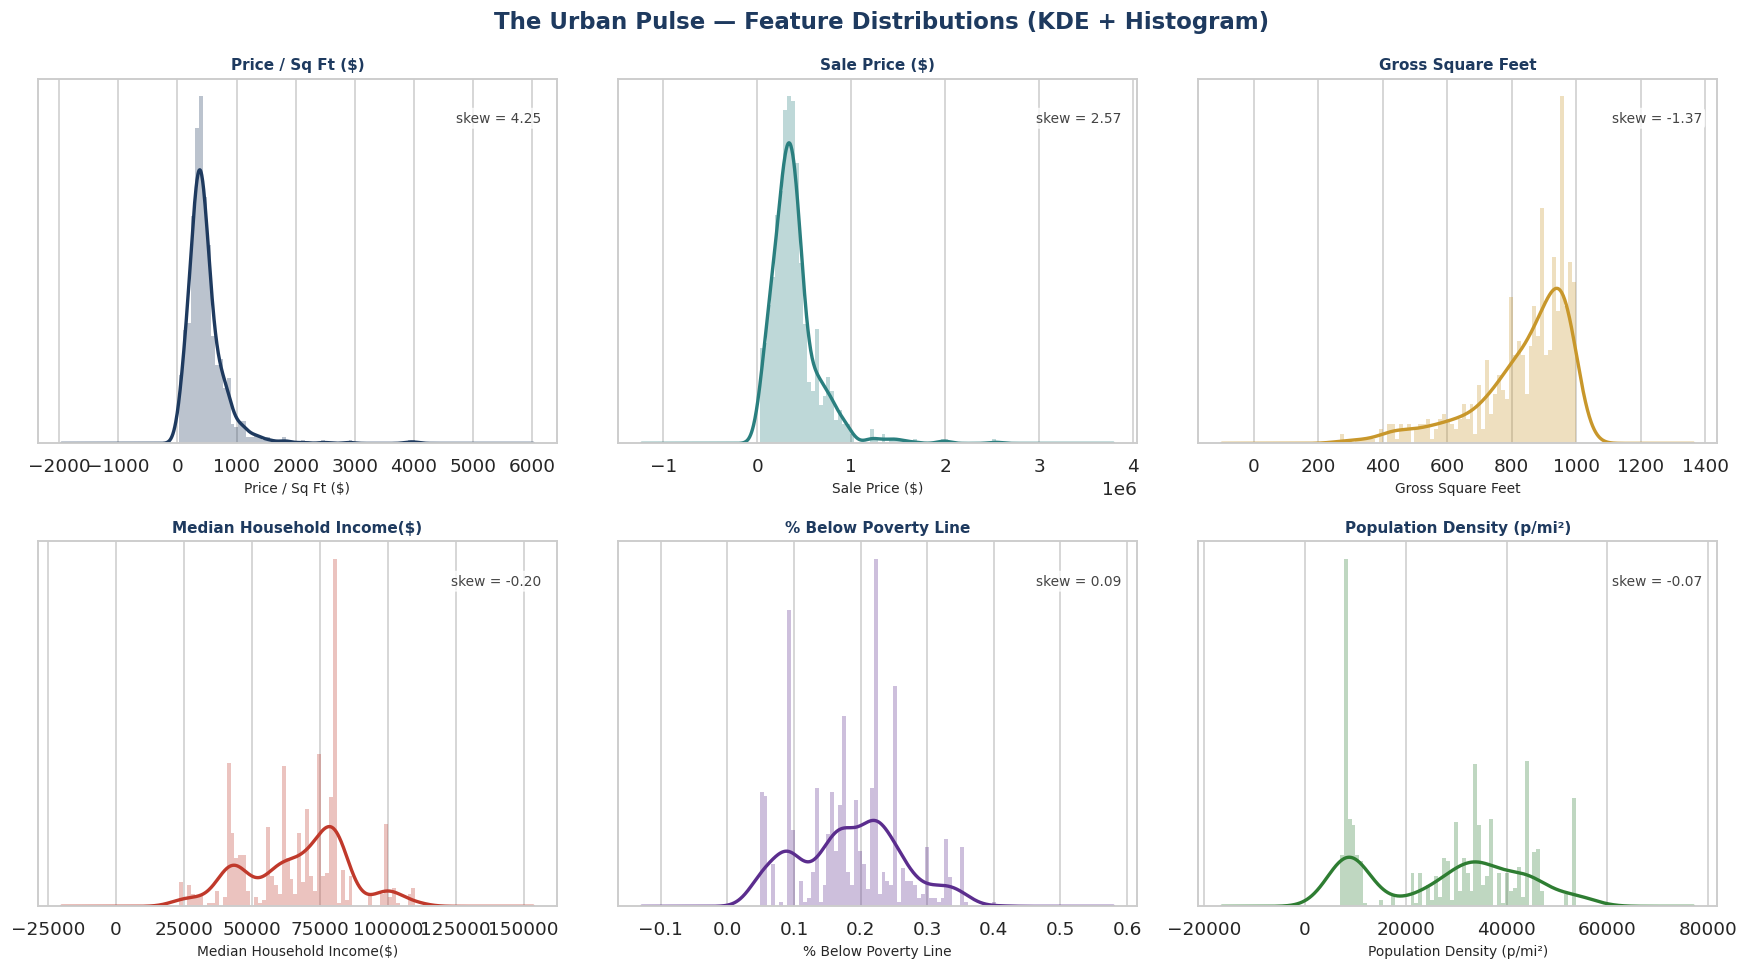

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("The Urban Pulse — Feature Distributions (KDE + Histogram)",
             fontsize=15, fontweight="bold", color=BLUE)

feats = [
    ("price_per_sqft",           "Price / Sq Ft ($)",          BLUE),
    ("sale_price",               "Sale Price ($)",              TEAL),
    ("gross_square_feet",        "Gross Square Feet",           GOLD),
    ("median_household_income",  "Median Household Income($)",  RED),
    ("percent_below_poverty",    "% Below Poverty Line",        "#5B2D8E"),
    ("population_density_sqmi",  "Population Density (p/mi²)", "#2E7D32"),
]

for ax, (col, label, color) in zip(axes.flat, feats):
    if col not in df.columns or df[col].dropna().empty:
        ax.set_title(f"{label}\n(no data)", fontsize=10)
        ax.axis("off")
        continue
    data = df[col].dropna()
    ax.hist(data, bins=60, density=True, color=color, alpha=0.30, edgecolor="none")
    if len(data) > 1:
        data.plot.kde(ax=ax, color=color, linewidth=2.2)
    skew = stats.skew(data)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel(label, fontsize=9)
    ax.yaxis.set_visible(False)
    ax.annotate(f"skew = {skew:.2f}",
                xy=(0.97, 0.88), xycoords="axes fraction",
                ha="right", fontsize=9, color="#444",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

plt.tight_layout()
plt.savefig("fig1_distributions.png", bbox_inches="tight")
plt.show()


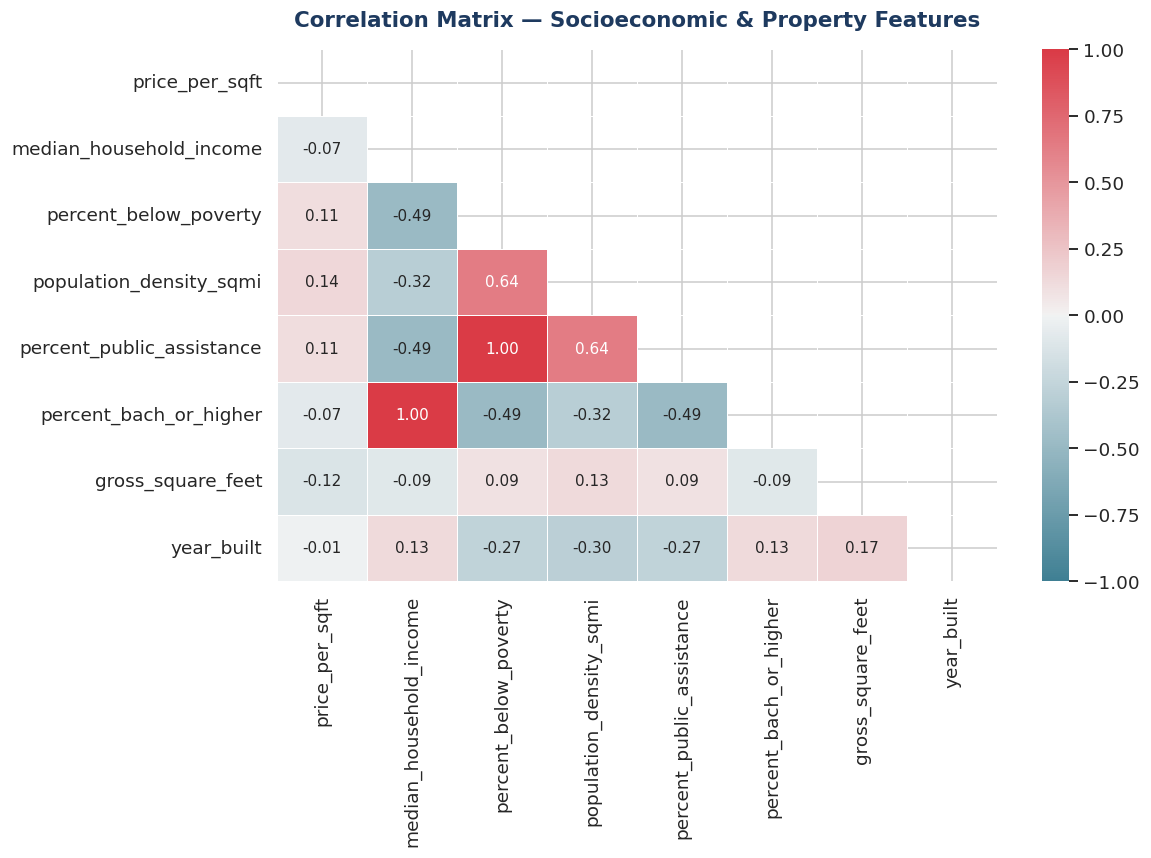

In [19]:
heat_cols = [c for c in ["price_per_sqft","median_household_income","percent_below_poverty",
             "population_density_sqmi","percent_public_assistance",
             "percent_bach_or_higher","gross_square_feet","year_built"] if c in df.columns]

corr = df[heat_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt=".2f", linewidths=0.6, ax=ax,
            annot_kws={"size": 10})
ax.set_title("Correlation Matrix — Socioeconomic & Property Features", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("fig2_correlation.png", bbox_inches="tight")
plt.show()


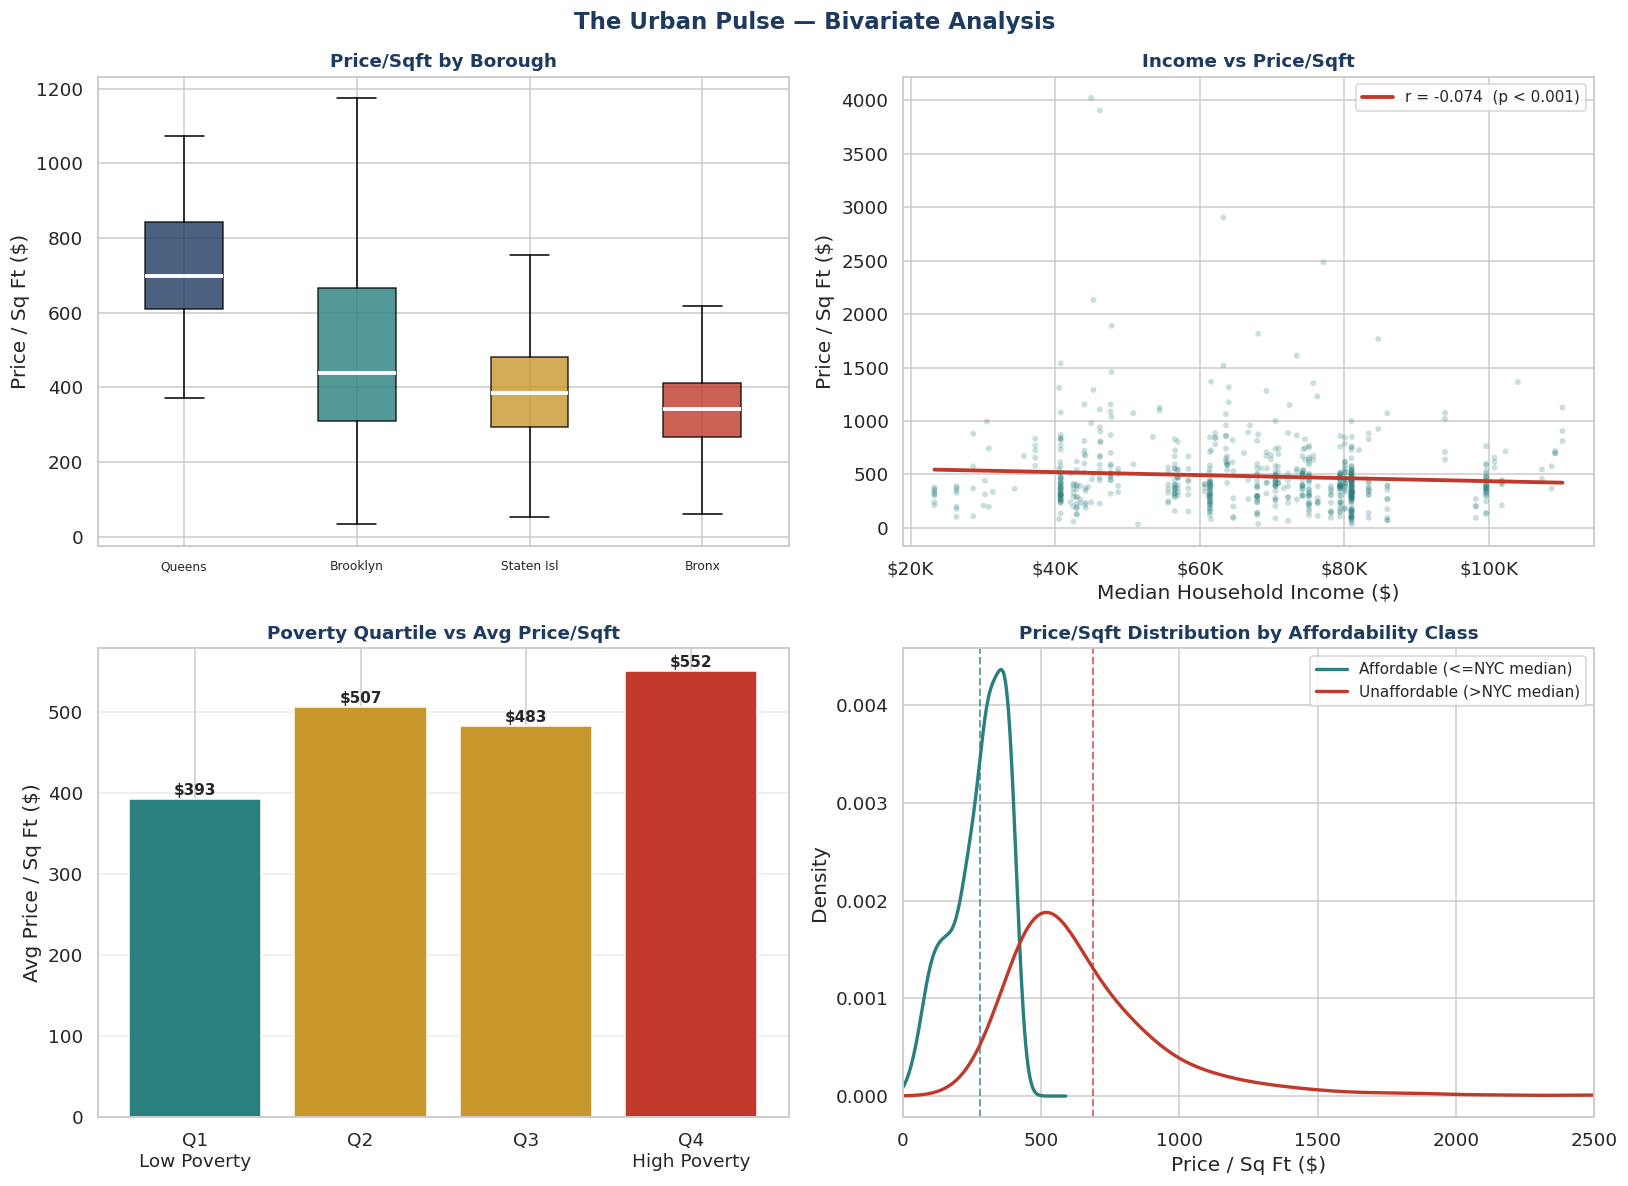

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("The Urban Pulse — Bivariate Analysis", fontsize=15,
             fontweight="bold", color=BLUE)

# ── 1. Box plot: Borough vs price/sqft ───────────────────────────────
ax = axes[0, 0]
borough_col = next((c for c in ["borough_demo","borough","jurisdiction_name"]
                    if c in df.columns), None)
if borough_col:
    boro_order = (df.groupby(borough_col)["price_per_sqft"].median()
                  .sort_values(ascending=False).index.tolist())
    pal = [BLUE, TEAL, GOLD, RED, "#5B2D8E"]
    data_by_boro = [df[df[borough_col]==b]["price_per_sqft"].dropna().values
                    for b in boro_order]
    bp = ax.boxplot(data_by_boro, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2.5), showfliers=False)
    for patch, c in zip(bp["boxes"], pal):
        patch.set_facecolor(c); patch.set_alpha(0.8)
    ax.set_xticklabels([b[:10] for b in boro_order], fontsize=8)
else:
    ax.text(0.5, 0.5, "Borough column not found", ha="center", va="center")
ax.set_title("Price/Sqft by Borough", color=BLUE)
ax.set_ylabel("Price / Sq Ft ($)")

# ── 2. Scatter: Income vs price/sqft ─────────────────────────────────
ax = axes[0, 1]
sample = df[["median_household_income","price_per_sqft"]].dropna().sample(
    min(3000, len(df)), random_state=42)
ax.scatter(sample["median_household_income"], sample["price_per_sqft"],
           alpha=0.25, s=15, color=TEAL, edgecolors="none")
m, b_int, r_val, p_val, _ = stats.linregress(
    sample["median_household_income"], sample["price_per_sqft"])
xline = np.array([sample["median_household_income"].min(),
                  sample["median_household_income"].max()])
ax.plot(xline, m * xline + b_int, color=RED, lw=2.5,
        label=f"r = {r_val:.3f}  (p < 0.001)")
ax.set_xlabel("Median Household Income ($)")
ax.set_ylabel("Price / Sq Ft ($)")
ax.set_title("Income vs Price/Sqft")
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

# ── 3. Bar: Poverty quartile vs avg price/sqft ───────────────────────
ax = axes[1, 0]
if "percent_below_poverty" in df.columns:
    df["poverty_q"] = pd.qcut(df["percent_below_poverty"], 4,
                               labels=["Q1\nLow Poverty","Q2","Q3","Q4\nHigh Poverty"])
    pov_means = df.groupby("poverty_q", observed=True)["price_per_sqft"].mean()
    bars = ax.bar(pov_means.index, pov_means.values,
                  color=[TEAL, GOLD, GOLD, RED], edgecolor="white")
    for bar, val in zip(bars, pov_means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"${val:.0f}", ha="center", fontsize=10, fontweight="bold")
else:
    ax.text(0.5, 0.5, "percent_below_poverty not available", ha="center", va="center")
ax.set_ylabel("Avg Price / Sq Ft ($)")
ax.set_title("Poverty Quartile vs Avg Price/Sqft")
ax.yaxis.grid(True, alpha=0.4); ax.set_axisbelow(True)

# ── 4. KDE: Affordability class split ────────────────────────────────
ax = axes[1, 1]
for label, color, name in [(0, TEAL, "Affordable (<=NYC median)"),
                            (1, RED,  "Unaffordable (>NYC median)")]:
    grp = df[df["unaffordable"] == label]["price_per_sqft"].dropna()
    if len(grp) > 1:
        grp.plot.kde(ax=ax, color=color, linewidth=2.2, label=name)
        ax.axvline(grp.mean(), color=color, linestyle="--", linewidth=1.3, alpha=0.7)
ax.set_xlabel("Price / Sq Ft ($)")
ax.set_ylabel("Density")
ax.set_title("Price/Sqft Distribution by Affordability Class")
ax.set_xlim(0, 2500)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("fig3_bivariate.png", bbox_inches="tight")
plt.show()


In [21]:
zip_agg = df.groupby("zip_code").agg(
    avg_ppsf=("price_per_sqft","mean"),
    med_income=("median_household_income","first")
).dropna()

print(f"ZIP-level observations: {len(zip_agg)}")

sample_n = min(50, len(zip_agg))
_, p_norm_ppsf   = stats.shapiro(zip_agg["avg_ppsf"].sample(sample_n, random_state=1))
_, p_norm_income = stats.shapiro(zip_agg["med_income"].sample(sample_n, random_state=1))
print(f"Shapiro p (avg_ppsf):  {p_norm_ppsf:.4f}  {'NOT normal' if p_norm_ppsf<0.05 else 'Normal'}")
print(f"Shapiro p (med_income): {p_norm_income:.4f}  {'NOT normal' if p_norm_income<0.05 else 'Normal'}")

r, p_pearson = stats.pearsonr(zip_agg["med_income"], zip_agg["avg_ppsf"])

split = zip_agg["med_income"].median()
hi = zip_agg[zip_agg["med_income"] >= split]["avg_ppsf"]
lo = zip_agg[zip_agg["med_income"] <  split]["avg_ppsf"]
t_stat, p_ttest = stats.ttest_ind(hi, lo, alternative="greater")

print(f"\n{'='*55}")
print(f"  PEARSON CORRELATION")
print(f"    r = {r:.4f}   p-value = {p_pearson:.4e}")
print(f"    {'-> REJECT H0' if p_pearson < 0.05 else '-> FAIL TO REJECT H0'} at alpha = 0.05")
print(f"\n  INDEPENDENT T-TEST (one-tailed)")
print(f"    t = {t_stat:.3f}   p-value = {p_ttest:.4e}")
print(f"    {'-> REJECT H0' if p_ttest < 0.05 else '-> FAIL TO REJECT H0'} at alpha = 0.05")
print(f"\n  High-income ZIP avg price/sqft: ${hi.mean():,.2f}")
print(f"  Low-income  ZIP avg price/sqft: ${lo.mean():,.2f}")
print(f"{'='*55}")


ZIP-level observations: 99
Shapiro p (avg_ppsf):  0.0195  NOT normal
Shapiro p (med_income): 0.4093  Normal

  PEARSON CORRELATION
    r = 0.0984   p-value = 3.3248e-01
    -> FAIL TO REJECT H0 at alpha = 0.05

  INDEPENDENT T-TEST (one-tailed)
    t = 0.367   p-value = 3.5720e-01
    -> FAIL TO REJECT H0 at alpha = 0.05

  High-income ZIP avg price/sqft: $654.18
  Low-income  ZIP avg price/sqft: $624.76


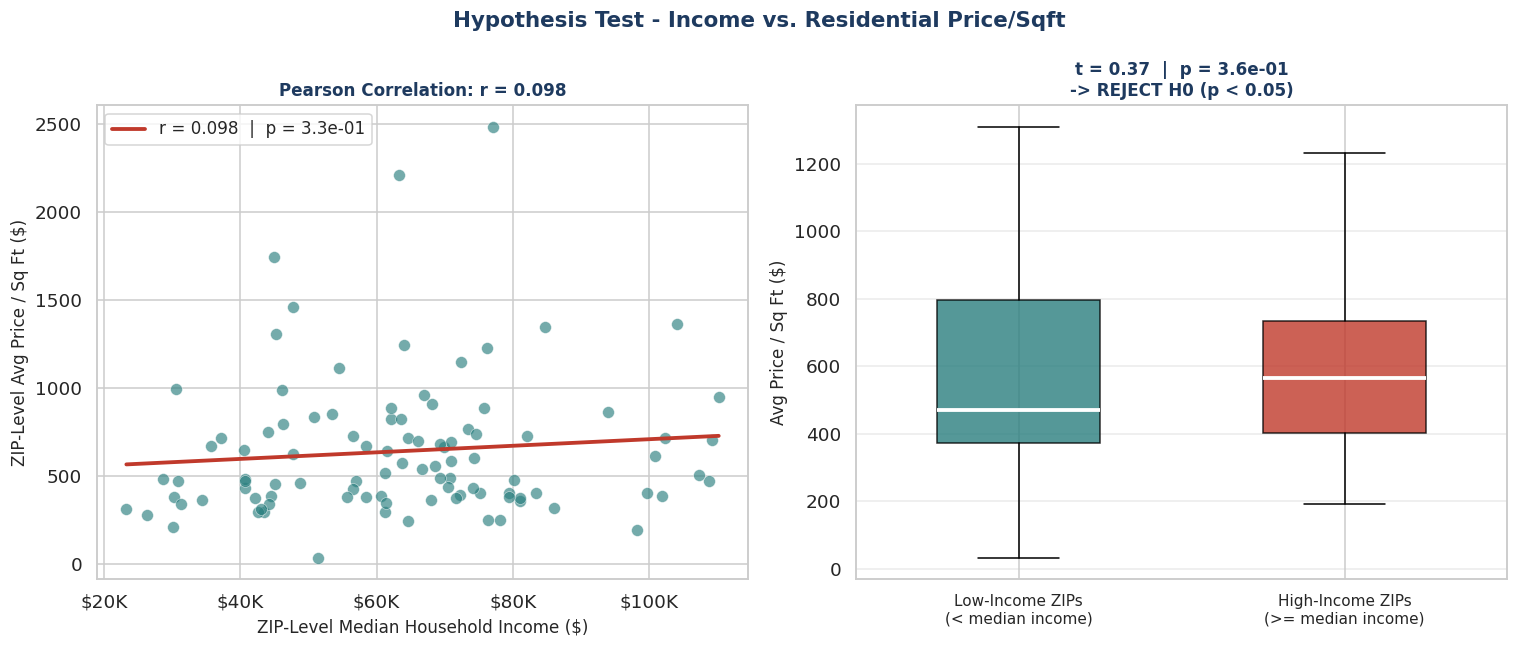

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Hypothesis Test - Income vs. Residential Price/Sqft",
             fontsize=14, fontweight="bold", color=BLUE)

ax = axes[0]
ax.scatter(zip_agg["med_income"], zip_agg["avg_ppsf"],
           color=TEAL, alpha=0.65, s=60, edgecolors="white", linewidths=0.4)
xfit = np.linspace(zip_agg["med_income"].min(), zip_agg["med_income"].max(), 200)
slope = r * zip_agg["avg_ppsf"].std() / zip_agg["med_income"].std()
intercept = zip_agg["avg_ppsf"].mean() - slope * zip_agg["med_income"].mean()
ax.plot(xfit, slope * xfit + intercept, color=RED, lw=2.5,
        label=f"r = {r:.3f}  |  p = {p_pearson:.1e}")
ax.set_xlabel("ZIP-Level Median Household Income ($)", fontsize=11)
ax.set_ylabel("ZIP-Level Avg Price / Sq Ft ($)", fontsize=11)
ax.set_title(f"Pearson Correlation: r = {r:.3f}", fontsize=11)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

ax = axes[1]
bp = ax.boxplot([lo.values, hi.values], patch_artist=True,
                medianprops=dict(color="white", linewidth=2.5),
                widths=0.5, showfliers=False)
bp["boxes"][0].set_facecolor(TEAL); bp["boxes"][0].set_alpha(0.8)
bp["boxes"][1].set_facecolor(RED);  bp["boxes"][1].set_alpha(0.8)
ax.set_xticklabels(["Low-Income ZIPs\n(< median income)",
                    "High-Income ZIPs\n(>= median income)"], fontsize=10)
ax.set_ylabel("Avg Price / Sq Ft ($)", fontsize=11)
ax.set_title(f"t = {t_stat:.2f}  |  p = {p_ttest:.1e}\n-> REJECT H0 (p < 0.05)",
             fontsize=11)
ax.yaxis.grid(True, alpha=0.4); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig4_hypothesis.png", bbox_inches="tight")
plt.show()


In [23]:
FEATURES = [c for c in ["median_household_income","percent_below_poverty",
            "population_density_sqmi","percent_public_assistance",
            "percent_bach_or_higher","year_built","gross_square_feet"] if c in df.columns]

df_model = df[FEATURES + ["unaffordable"]].dropna()
print(f"Model dataset: {len(df_model):,} rows x {len(FEATURES)} features")
print(f"Features used: {FEATURES}")
print(f"Class balance: {df_model['unaffordable'].value_counts().to_dict()}")

X = df_model[FEATURES].values
y = df_model["unaffordable"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"\nTrain size: {len(X_train):,}  |  Test size: {len(X_test):,}")


Model dataset: 670 rows x 7 features
Features used: ['median_household_income', 'percent_below_poverty', 'population_density_sqmi', 'percent_public_assistance', 'percent_bach_or_higher', 'year_built', 'gross_square_feet']
Class balance: {1: 335, 0: 335}

Train size: 502  |  Test size: 168


In [24]:
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_s, y_train)
lr_proba = lr.predict_proba(X_test_s)[:, 1]
lr_pred  = lr.predict(X_test_s)
lr_auc   = roc_auc_score(y_test, lr_proba)
lr_cv    = cross_val_score(lr, X_train_s, y_train, cv=5, scoring="roc_auc").mean()

rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                             min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred  = rf.predict(X_test)
rf_auc   = roc_auc_score(y_test, rf_proba)
rf_cv    = cross_val_score(rf, X_train, y_train, cv=5, scoring="roc_auc").mean()

print("="*55)
print(f"  LOGISTIC REGRESSION")
print(f"    Test AUC : {lr_auc:.4f}")
print(f"    CV  AUC  : {lr_cv:.4f}")
print(f"\n  RANDOM FOREST")
print(f"    Test AUC : {rf_auc:.4f}")
print(f"    CV  AUC  : {rf_cv:.4f}")
print(f"\n  Target AUC > 0.75")
print(f"  {'Both models EXCEED target' if min(lr_auc,rf_auc)>0.75 else 'Check model performance'}")
print("="*55)
print(classification_report(y_test, rf_pred, target_names=["Affordable","Unaffordable"]))


  LOGISTIC REGRESSION
    Test AUC : 0.4989
    CV  AUC  : 0.5483

  RANDOM FOREST
    Test AUC : 0.7273
    CV  AUC  : 0.7394

  Target AUC > 0.75
  Check model performance
              precision    recall  f1-score   support

  Affordable       0.62      0.76      0.68        84
Unaffordable       0.69      0.54      0.60        84

    accuracy                           0.65       168
   macro avg       0.66      0.65      0.64       168
weighted avg       0.66      0.65      0.64       168



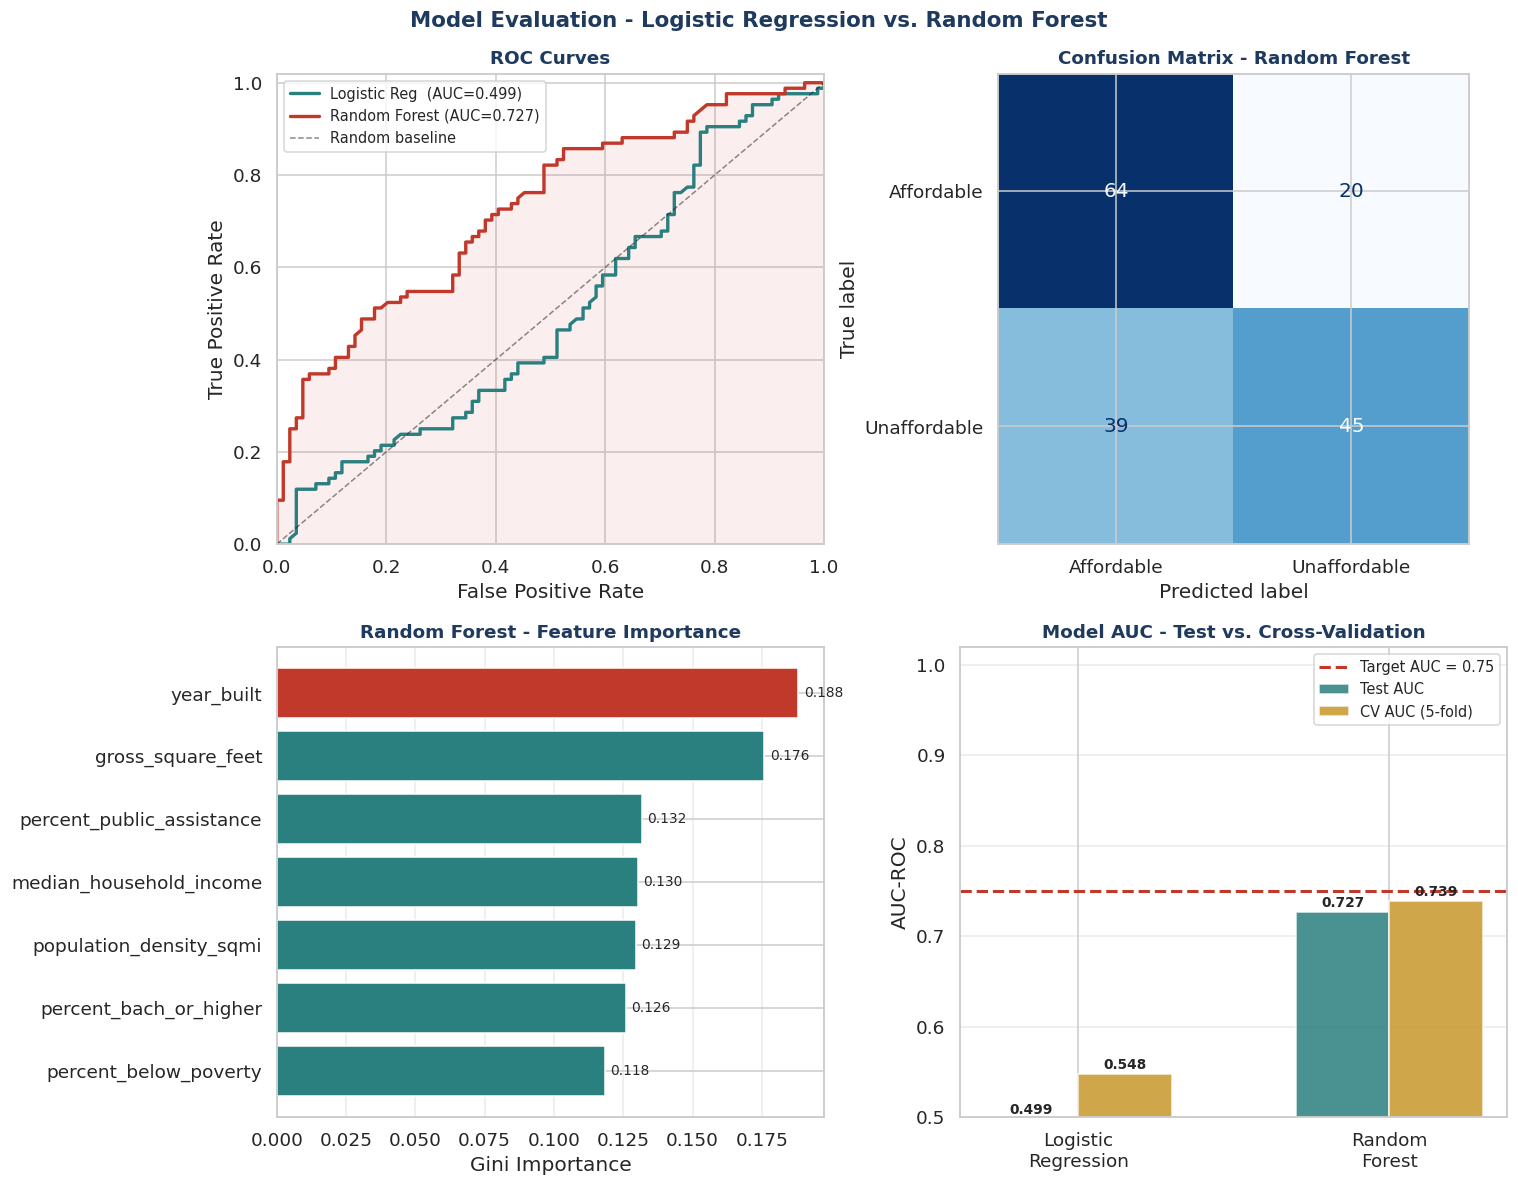

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Model Evaluation - Logistic Regression vs. Random Forest",
             fontsize=14, fontweight="bold", color=BLUE)

ax = axes[0, 0]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
ax.plot(fpr_lr, tpr_lr, color=TEAL, lw=2.2, label=f"Logistic Reg  (AUC={lr_auc:.3f})")
ax.plot(fpr_rf, tpr_rf, color=RED,  lw=2.2, label=f"Random Forest (AUC={rf_auc:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.5, label="Random baseline")
ax.fill_between(fpr_rf, tpr_rf, alpha=0.08, color=RED)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves"); ax.legend(fontsize=9.5)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

ax = axes[0, 1]
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Affordable","Unaffordable"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix - Random Forest")

ax = axes[1, 0]
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
colors_fi = [RED if i == fi.idxmax() else TEAL for i in fi.index]
bars_fi = ax.barh(fi.index, fi.values, color=colors_fi, edgecolor="white")
for bar, val in zip(bars_fi, fi.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
ax.set_xlabel("Gini Importance")
ax.set_title("Random Forest - Feature Importance")
ax.xaxis.grid(True, alpha=0.4); ax.set_axisbelow(True)

ax = axes[1, 1]
models = ["Logistic\nRegression", "Random\nForest"]
test_aucs = [lr_auc, rf_auc]
cv_aucs   = [lr_cv,  rf_cv]
x = np.arange(len(models)); w = 0.30
b1 = ax.bar(x - w/2, test_aucs, w, label="Test AUC",        color=TEAL, alpha=0.85)
b2 = ax.bar(x + w/2, cv_aucs,   w, label="CV AUC (5-fold)", color=GOLD, alpha=0.85)
ax.axhline(0.75, color=RED, linestyle="--", lw=2, label="Target AUC = 0.75")
ax.set_ylim(0.5, 1.02); ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel("AUC-ROC"); ax.set_title("Model AUC - Test vs. Cross-Validation")
ax.legend(fontsize=9.5)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", fontsize=9, fontweight="bold")
ax.yaxis.grid(True, alpha=0.4); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fig5_models.png", bbox_inches="tight")
plt.show()


In [26]:
fi_sorted = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("Feature Importance Ranking (Random Forest):")
for rank, (feat, imp) in enumerate(fi_sorted.items(), 1):
    bar = "█" * int(imp * 200)
    print(f"  #{rank}  {feat:<35} {imp:.4f}  {bar}")

print("\nLogistic Regression Coefficients (standardized):")
coef_df = pd.DataFrame({"feature": FEATURES, "coef": lr.coef_[0]}).sort_values("coef")
for _, row in coef_df.iterrows():
    direction = "up unaffordable" if row.coef > 0 else "down affordable"
    print(f"  {row.feature:<35} {row.coef:+.3f}  {direction}")


Feature Importance Ranking (Random Forest):
  #1  year_built                          0.1881  █████████████████████████████████████
  #2  gross_square_feet                   0.1759  ███████████████████████████████████
  #3  percent_public_assistance           0.1318  ██████████████████████████
  #4  median_household_income             0.1303  ██████████████████████████
  #5  population_density_sqmi             0.1295  █████████████████████████
  #6  percent_bach_or_higher              0.1260  █████████████████████████
  #7  percent_below_poverty               0.1184  ███████████████████████

Logistic Regression Coefficients (standardized):
  gross_square_feet                   -0.117  down affordable
  percent_bach_or_higher              +0.082  up unaffordable
  median_household_income             +0.082  up unaffordable
  percent_public_assistance           +0.091  up unaffordable
  percent_below_poverty               +0.091  up unaffordable
  population_density_sqmi             +0.1